In [ ]:
import os
os.chdir(r'C:\Users\annie\STAT 426 Deep Learning\gas price')
print(os.getcwd())

C:\Users\annie\STAT 426 Deep Learning\gas price


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy, itertools

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from itertools import product as iter_product
from warnings import catch_warnings, simplefilter
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(41)
np.random.seed(41)

%matplotlib inline

Using device: cpu


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD & MERGE DATA
# ─────────────────────────────────────────────────────────────────────────────

gas  = pd.read_excel('gas.xls', sheet_name='Data 1', skiprows=3, usecols='A:B')                  # target
util = pd.read_excel('WPULEUS3w.xls', sheet_name='Data 1', skiprows=2)                           # refinery utilization rate
wti  = pd.read_csv('WCOILWTICO.csv')                                                             # crude oil price
padd = pd.read_csv('Weekly_West_Coast_(PADD_5)_Ending_Stocks_of_Total_Gasoline.csv', skiprows=4) # PADD 5 gasoline inventories
supp = pd.read_csv('Weekly_U.S._Product_Supplied_of_Finished_Motor_Gasoline.csv', skiprows=4)    # U.S. product supplied of finished motor gasoline

# Rename columns
gas.columns  = ['date', 'gas_price']         # Retail Gasoline Price
wti.columns  = ['date', 'wti_price']         # Crude Oil Price
padd.columns = ['date', 'padd5_inventory']   # Gasoline Inventory (West Coast)
util.columns = ['date', 'refinery_util']     # Refinery Utilization Rate
supp.columns = ['date', 'product_supplied']  # Product Supplied of Finished Motor Gasoline (Thousand Barrels per Day)

# Convert date columns
for frame in [gas, wti, padd, util, supp]:
    frame['date'] = pd.to_datetime(frame['date'])

# Sort ascending where needed (PADD and supp files are descending by default)
for frame in [padd, util, supp]:
    frame.sort_values('date', inplace=True)
    frame.reset_index(drop=True, inplace=True)

# Clip all series to start date
START = '2000-05-22'
gas  = gas[gas['date']   >= START].reset_index(drop=True)
wti  = wti[wti['date']   >= START].reset_index(drop=True)
padd = padd[padd['date'] >= START].reset_index(drop=True)
util = util[util['date'] >= START].reset_index(drop=True)
supp = supp[supp['date'] >= START].reset_index(drop=True)

# Smooth product_supplied 4-week rolling mean
supp['product_supplied'] = supp['product_supplied'].rolling(window=4, min_periods=1).mean()

# Merge all series on nearest date
tol = pd.Timedelta('7 days')
df = (
    gas.sort_values('date')
       .pipe(pd.merge_asof, wti.sort_values('date'),  on='date', direction='nearest', tolerance=tol)
       .pipe(pd.merge_asof, padd.sort_values('date'), on='date', direction='nearest', tolerance=tol)
       .pipe(pd.merge_asof, util.sort_values('date'), on='date', direction='nearest', tolerance=tol)
       .pipe(pd.merge_asof, supp.sort_values('date'), on='date', direction='nearest', tolerance=tol)
       .sort_values('date')
       .dropna()
       .reset_index(drop=True)
)

print(df.head())
print(f"Dataset shape: {df.shape}")
print(df.isnull().sum())

        date  gas_price  wti_price  padd5_inventory  refinery_util  \
0 2000-05-22      1.679      29.46            30027           95.3   
1 2000-05-29      1.673      29.46            30027           95.3   
2 2000-06-05      1.661      29.98            29764           95.6   
3 2000-06-12      1.662      29.79            29340           95.0   
4 2000-06-19      1.664      32.45            28965           96.1   

   product_supplied  
0       9075.000000  
1       9075.000000  
2       8969.000000  
3       8780.333333  
4       8809.000000  
Dataset shape: (1343, 6)
date                0
gas_price           0
wti_price           0
padd5_inventory     0
refinery_util       0
product_supplied    0
dtype: int64


In [4]:
SEQ_LENGTH    = 12     
BATCH_SIZE    = 32

n         = len(df)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

print(f"Train: 0–{train_end} | Val: {train_end}–{val_end} | Test: {val_end}–{n}")
print(f"SEQ_LENGTH: {SEQ_LENGTH} weeks")


Train: 0–1074 | Val: 1074–1208 | Test: 1208–1343
SEQ_LENGTH: 12 weeks


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# NORMALIZE TRAINING DATA
# ─────────────────────────────────────────────────────────────────────────────

scaler_multi = MinMaxScaler()
data_multi = df[['gas_price', 'wti_price', 'padd5_inventory', 'refinery_util', 'product_supplied']].values

# Fit scaler on train ONLY to avoid leakage
scaler_multi.fit(data_multi[:train_end])
scaled_multi = scaler_multi.transform(data_multi)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPARE SEQUENCES  
# ─────────────────────────────────────────────────────────────────────────────

def create_sequences(data, seq_len):
    """Return (X, y) where y is the next gas_price after each window."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len, 0])
    return np.array(X), np.array(y)

# Split scaled data
train_scaled = scaled_multi[:train_end]
val_scaled   = scaled_multi[train_end:val_end]
test_scaled  = scaled_multi[val_end:]

# Train: sequences built within train only
Xtr_m, ytr_m = create_sequences(train_scaled, SEQ_LENGTH)

# Val: prepend last SEQ_LENGTH rows of train as context
val_context  = np.concatenate([scaled_multi[train_end - SEQ_LENGTH:train_end], val_scaled], axis=0)
Xva_m, yva_m = create_sequences(val_context, SEQ_LENGTH)

# Test: prepend last SEQ_LENGTH rows of val as context
test_context = np.concatenate([scaled_multi[val_end - SEQ_LENGTH:val_end], test_scaled], axis=0)
Xte_m, yte_m = create_sequences(test_context, SEQ_LENGTH)

ytr_m = ytr_m.reshape(-1, 1)
yva_m = yva_m.reshape(-1, 1)
yte_m = yte_m.reshape(-1, 1)

print(f"Train: {Xtr_m.shape}  Val: {Xva_m.shape}  Test: {Xte_m.shape}")

Train: (1062, 12, 5)  Val: (134, 12, 5)  Test: (135, 12, 5)


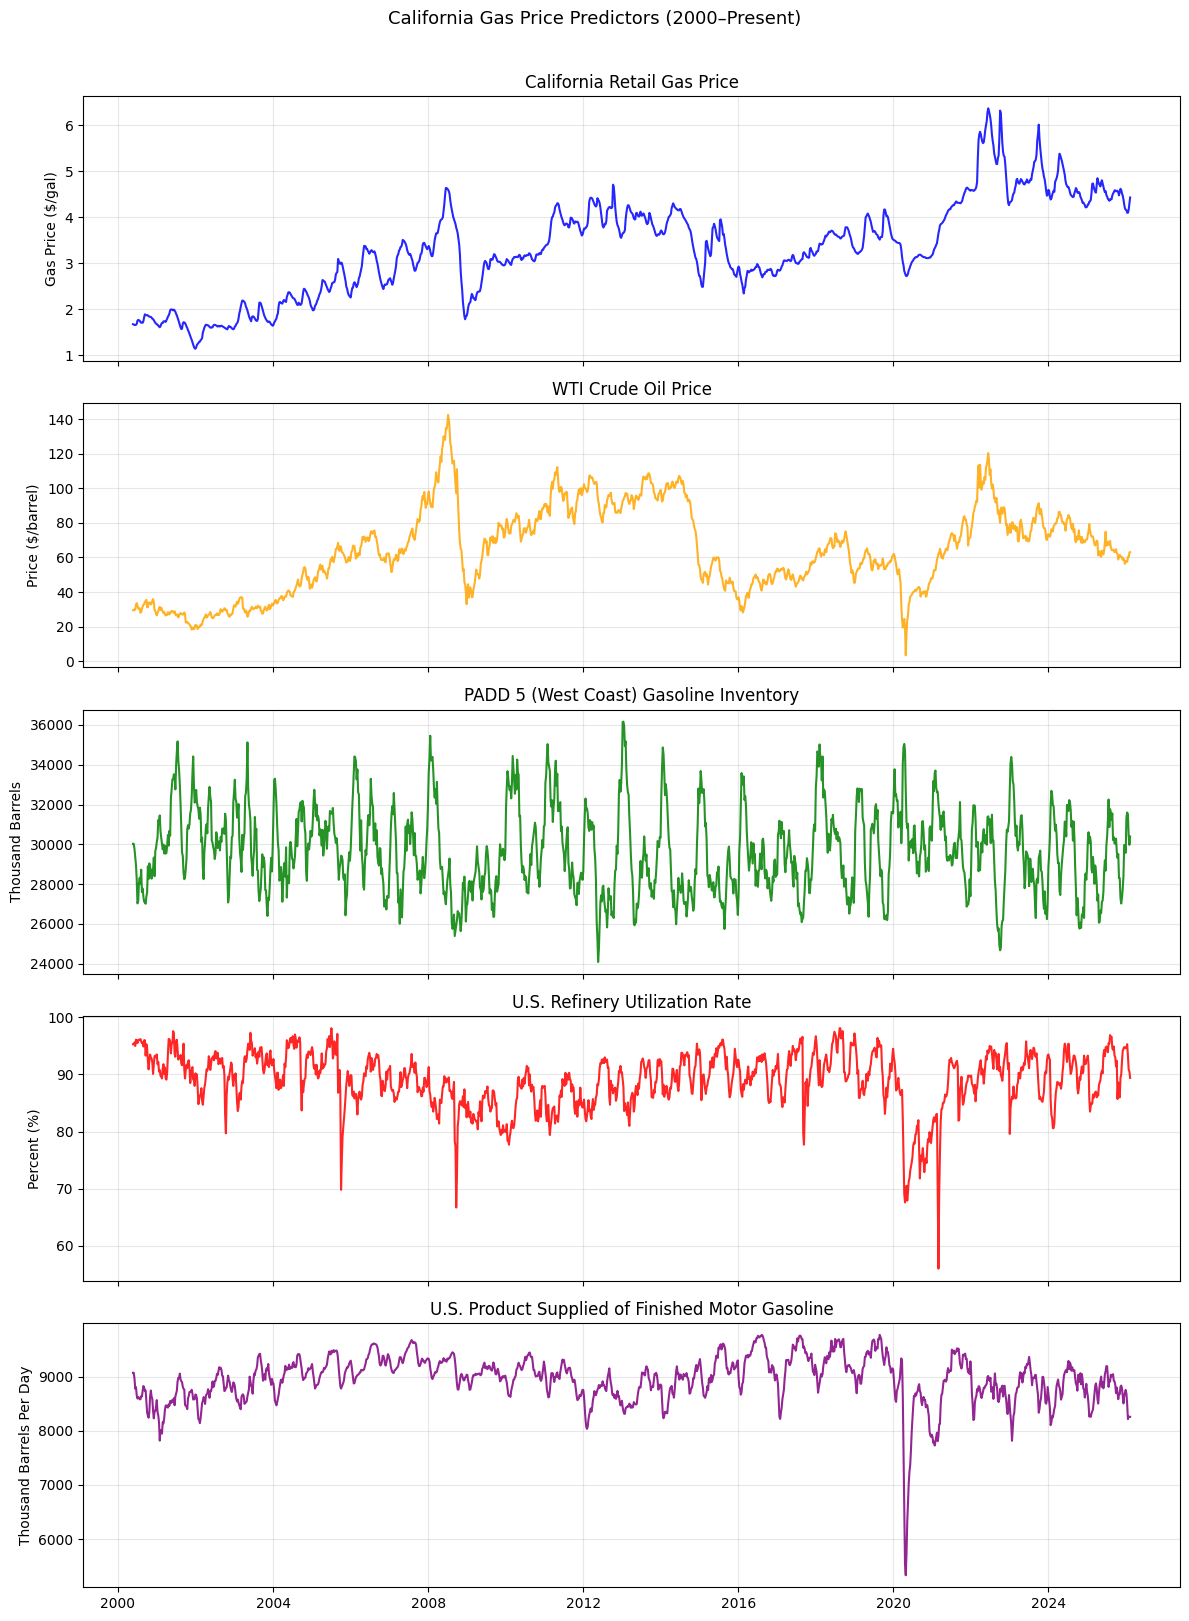


Correlation:
                   gas_price  wti_price  padd5_inventory  refinery_util  \
gas_price            1.0000     0.7627          -0.1841        -0.0524   
wti_price            0.7627     1.0000          -0.1032        -0.1454   
padd5_inventory     -0.1841    -0.1032           1.0000        -0.1062   
refinery_util       -0.0524    -0.1454          -0.1062         1.0000   
product_supplied     0.0125     0.1084          -0.2514         0.4481   

                  product_supplied  
gas_price                   0.0125  
wti_price                   0.1084  
padd5_inventory            -0.2514  
refinery_util               0.4481  
product_supplied            1.0000  


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

FEATURE_COLS = ['gas_price', 'wti_price', 'padd5_inventory', 'refinery_util', 'product_supplied']

PLOT_META = [
    ('gas_price',        'blue',   'Gas Price ($/gal)',         'California Retail Gas Price'),
    ('wti_price',        'orange', 'Price ($/barrel)',          'WTI Crude Oil Price'),
    ('padd5_inventory',  'green',  'Thousand Barrels',          'PADD 5 (West Coast) Gasoline Inventory'),
    ('refinery_util',    'red',    'Percent (%)',               'U.S. Refinery Utilization Rate'),
    ('product_supplied', 'purple', 'Thousand Barrels Per Day',  'U.S. Product Supplied of Finished Motor Gasoline')
]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)  # fix: height was 10, too cramped for 5 panels
for ax, (col, color, ylabel, title) in zip(axes, PLOT_META):
    ax.plot(df['date'], df[col], color=color, alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('California Gas Price Predictors (2000–Present)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nCorrelation:\n", df[FEATURE_COLS].corr().round(4))

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMA-X BASELINE WITH GRID SEARCH
# ─────────────────────────────────────────────────────────────────────────────

# ── ADD SEASONAL FEATURES ─────────────────────────────────────────────────
dt = pd.to_datetime(df['date'])
m = dt.dt.month - 1
df['month_cos'] = np.cos(2*np.pi*m/12)
df['month_sin'] = np.sin(2*np.pi*m/12)

X_COLS = ['wti_price','padd5_inventory','month_cos','month_sin','refinery_util','product_supplied']

# ── TRAIN / VAL / TEST SPLITS ─────────────────────────────────────────────
y_train_arima = df['gas_price'].iloc[:train_end].astype(float)
X_train_arima = df[X_COLS].iloc[:train_end].astype(float)

y_val_arima   = df['gas_price'].iloc[train_end:val_end].astype(float)
X_val_arima   = df[X_COLS].iloc[train_end:val_end].astype(float)

y_test_arima  = df['gas_price'].iloc[val_end:].astype(float)
X_test_arima  = df[X_COLS].iloc[val_end:].astype(float)

  ADF p-value: 0.1277 — non-stationary, use d=1


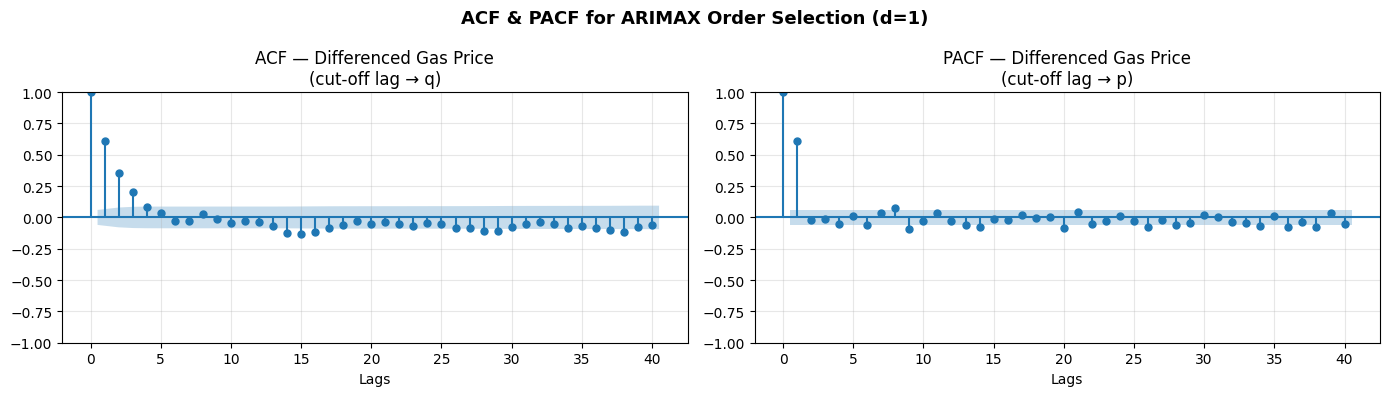

In [ ]:
# ── STATIONARITY CHECK ────────────────────────────────────────────────────
adf_result = adfuller(df['gas_price'].iloc[:train_end])
print(f"  ADF p-value: {adf_result[1]:.4f} — {'non-stationary, use d=1' if adf_result[1] > 0.05 else 'stationary'}")

d_values = [1] if adf_result[1] > 0.05 else [0, 1]

# ── ACF & PACF ──────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y_diff = y_train_arima.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_diff, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — Differenced Gas Price\n(cut-off lag → q)', fontsize=12)
axes[0].set_xlabel('Lags')
axes[0].grid(True, alpha=0.3)

plot_pacf(y_diff, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF — Differenced Gas Price\n(cut-off lag → p)', fontsize=12)
axes[1].set_xlabel('Lags')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ACF & PACF for ARIMAX Order Selection (d=1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMAX GRID SEARCH  
# ─────────────────────────────────────────────────────────────────────────────

print('Running ARIMAX grid search...')
p_values = range(1, 3)
q_values = range(1, 3)

best_val_rmse = float('inf')
best_order    = None
results_log   = []

combos = list(iter_product(p_values, d_values, q_values))
print(f'  Testing {len(combos)} combinations...\n')

for count, (p, d, q) in enumerate(combos, 1):
    try:
        with catch_warnings():
            simplefilter('ignore')
            fit = SARIMAX(
                y_train_arima,
                exog=X_train_arima,
                order=(p, d, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=200)

            # 12-step-ahead validation — consistent with SEQ_LENGTH=12
            val_preds = fit.forecast(steps=12, exog=X_val_arima.iloc[:12])
            if np.any(np.abs(val_preds) > 100):
                continue

            val_rmse = np.sqrt(mean_squared_error(y_val_arima.iloc[:12], val_preds))
            results_log.append({'order': (p, d, q), 'AIC': fit.aic, 'Val_RMSE': val_rmse})

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_order    = (p, d, q)

            if count % 3 == 0:
                print(f'  [{count}/{len(combos)}] {(p,d,q)} — AIC: {fit.aic:.2f}  Val RMSE: {val_rmse:.4f}')
    except Exception:
        continue

results_df = pd.DataFrame(results_log).sort_values('Val_RMSE')
print(f'\n  Best order by Val RMSE: {best_order}  (Val RMSE: {best_val_rmse:.4f})')
print('\n  Top configurations:')
print(results_df.head(10).to_string(index=False))

Running ARIMAX grid search...
  Testing 4 combinations...

  [3/4] (2, 1, 1) — AIC: -3180.49  Val RMSE: 0.2058

  Best order by Val RMSE: (1, 1, 1)  (Val RMSE: 0.2056)

  Top configurations:
    order          AIC  Val_RMSE
(1, 1, 1) -3182.107730  0.205624
(2, 1, 1) -3180.488731  0.205837
(1, 1, 2) -3175.953901  0.206113
(2, 1, 2) -3171.996064  0.208054


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMAX ROLLING WINDOW TEST EVALUATION  (one-step-ahead)
# ─────────────────────────────────────────────────────────────────────────────
from warnings import catch_warnings, simplefilter

test_size       = len(df) - val_end
rolling_preds   = []
rolling_actuals = []

print(f'Rolling-window ARIMAX — {test_size} test steps, order={best_order}')
print('One-step-ahead, frozen parameters (fit once on train only)...\n')

# ── Fit ONCE on train only ───────────────────────────────────────────────────
with catch_warnings():
    simplefilter('ignore')
    frozen_model = SARIMAX(
        df['gas_price'].iloc[:train_end].astype(float),
        exog=df[X_COLS].iloc[:train_end].astype(float),
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

print(f'Model fit once on {train_end} observations. Rolling forward from val_end={val_end}...\n')

# ── Fast-forward state through validation set  ────────────────
current_res = frozen_model
for i in range(val_end - train_end):
    with catch_warnings():
        simplefilter('ignore')
        y_val  = df['gas_price'].iloc[[train_end + i]].astype(float)
        X_val  = df[X_COLS].iloc[[train_end + i]].astype(float)
        current_res = current_res.append(y_val, exog=X_val, refit=False)

print('State fast-forwarded through validation set.\n')

# ── Roll forward on test set ─────────────────────────────────────────────────
for i in range(test_size):
    try:
        with catch_warnings():
            simplefilter('ignore')
            X_next = df[X_COLS].iloc[[val_end + i]].astype(float)
            pred   = float(current_res.forecast(steps=1, exog=X_next).iloc[0])

            y_new       = df['gas_price'].iloc[[val_end + i]].astype(float)
            current_res = current_res.append(y_new, exog=X_next, refit=False)

    except Exception:
        pred = rolling_preds[-1] if rolling_preds else float(df['gas_price'].iloc[val_end - 1])

    rolling_preds.append(pred)
    rolling_actuals.append(float(df['gas_price'].iloc[val_end + i]))

    if (i + 1) % 20 == 0 or i == test_size - 1:
        print(f'  Step {i+1}/{test_size} complete')

# ── Metrics ──────────────────────────────────────────────────────────────────
rolling_preds   = np.array(rolling_preds)
rolling_actuals = np.array(rolling_actuals)

rmse_arima = np.sqrt(mean_squared_error(rolling_actuals, rolling_preds))
mae_arima  = mean_absolute_error(rolling_actuals, rolling_preds)
r2_arima   = r2_score(rolling_actuals, rolling_preds)
pcc_arima  = np.corrcoef(rolling_actuals, rolling_preds)[0, 1]

arima_preds = pd.Series(rolling_preds, index=df.index[val_end:val_end + test_size])

print(f'\nRolling ARIMAX {best_order} — RMSE: {rmse_arima:.4f}  MAE: {mae_arima:.4f}  '
      f'R²: {r2_arima:.4f}  PCC: {pcc_arima:.4f}')

Rolling-window ARIMAX — 135 test steps, order=(1, 1, 1)
One-step-ahead, frozen parameters (fit once on train only)...

Model fit once on 1074 observations. Rolling forward from val_end=1208...

State fast-forwarded through validation set.

  Step 20/135 complete
  Step 40/135 complete
  Step 60/135 complete
  Step 80/135 complete
  Step 100/135 complete
  Step 120/135 complete
  Step 135/135 complete

Rolling ARIMAX (1, 1, 1) — RMSE: 0.0701  MAE: 0.0491  R²: 0.9616  PCC: 0.9812


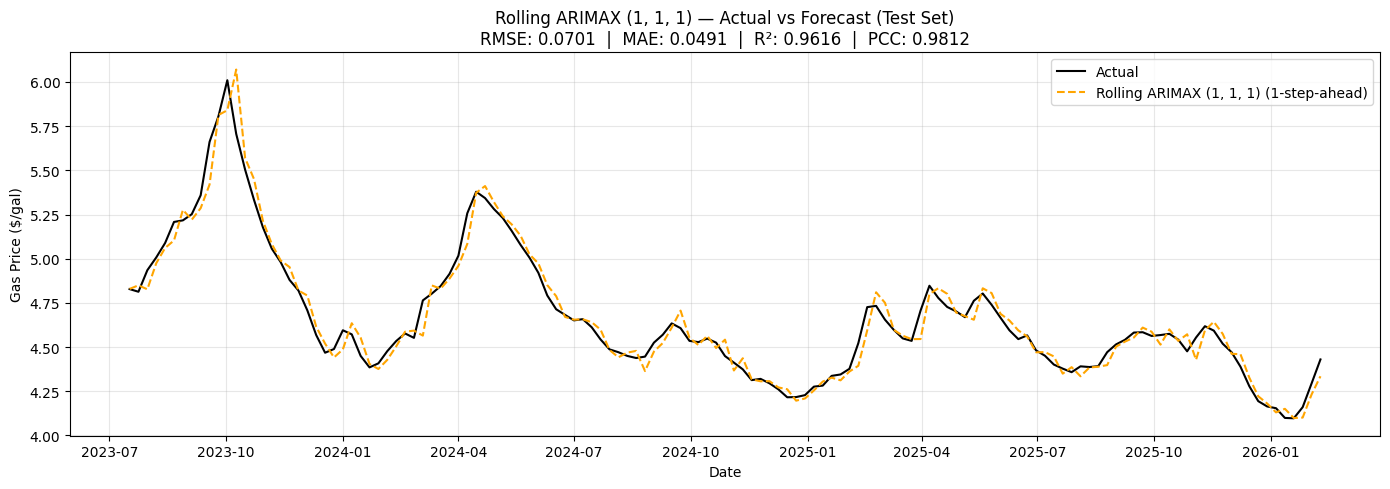

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMAX FORECAST PLOT
# ─────────────────────────────────────────────────────────────────────────────

test_dates_plot = df['date'].iloc[val_end:val_end + test_size].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates_plot, y_test_arima.values, linewidth=1.5, label='Actual', color='black')
ax.plot(test_dates_plot, arima_preds.values, linewidth=1.5, linestyle='--', color='orange', label=f'Rolling ARIMAX {best_order} (1-step-ahead)')

ax.set_title(
    f'Rolling ARIMAX {best_order} — Actual vs Forecast (Test Set)\n'
    f'RMSE: {rmse_arima:.4f}  |  MAE: {mae_arima:.4f}  |  '
    f'R²: {r2_arima:.4f}  |  PCC: {pcc_arima:.4f}'
)
ax.set_xlabel('Date')
ax.set_ylabel('Gas Price ($/gal)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

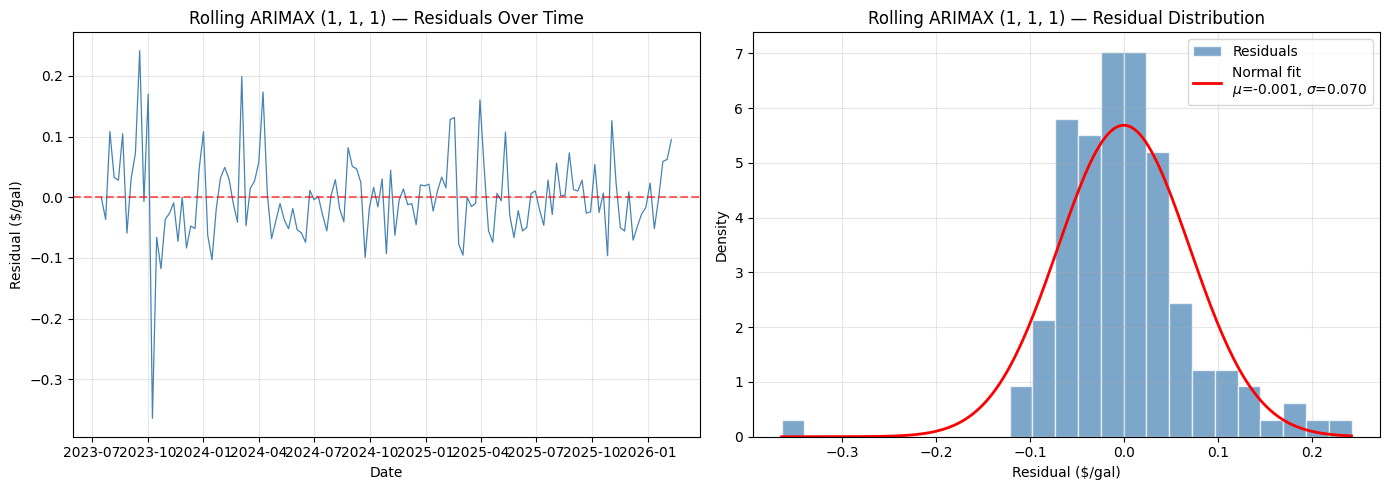

Residual stats — Mean: -0.0005  Std: 0.0701  Skew: -0.1885  Kurtosis: 5.4668
Durbin-Watson : 1.8915   (ideal ≈ 2.0)
Jarque-Bera p : 0.0000  ⚠ non-normal

Ljung-Box test (want p > 0.05):
      lb_stat  lb_pvalue
10  14.357188   0.157314
20  26.269932   0.157081


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMAX RESIDUAL DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────────────────

residuals       = rolling_actuals - rolling_preds
test_dates_plot = df['date'].iloc[val_end:val_end + test_size].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals over time
axes[0].plot(test_dates_plot, residuals, color='steelblue', linewidth=0.9)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_title(f'Rolling ARIMAX {best_order} — Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual ($/gal)')
axes[0].grid(True, alpha=0.3)

# residual distribution
mu, sigma = np.mean(residuals), np.std(residuals)
axes[1].hist(residuals, bins=25, density=True, color='steelblue',
             edgecolor='white', alpha=0.7, label='Residuals')
x_fit = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(x_fit, stats.norm.pdf(x_fit, mu, sigma), 'r-', linewidth=2,
             label=f'Normal fit\n$\\mu$={mu:.3f}, $\\sigma$={sigma:.3f}')
axes[1].set_title(f'Rolling ARIMAX {best_order} — Residual Distribution')
axes[1].set_xlabel('Residual ($/gal)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
lb      = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
dw      = durbin_watson(residuals)
jb_p    = stats.jarque_bera(residuals)[1]
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print(f'Residual stats — Mean: {mu:.4f}  Std: {sigma:.4f}  '
      f'Skew: {skewness:.4f}  Kurtosis: {kurtosis:.4f}')
print(f'Durbin-Watson : {dw:.4f}   (ideal ≈ 2.0)')
print(f'Jarque-Bera p : {jb_p:.4f}  {"⚠ non-normal" if jb_p < 0.05 else "✓ approx normal"}')
print(f'\nLjung-Box test (want p > 0.05):')
print(lb[['lb_stat', 'lb_pvalue']].to_string())


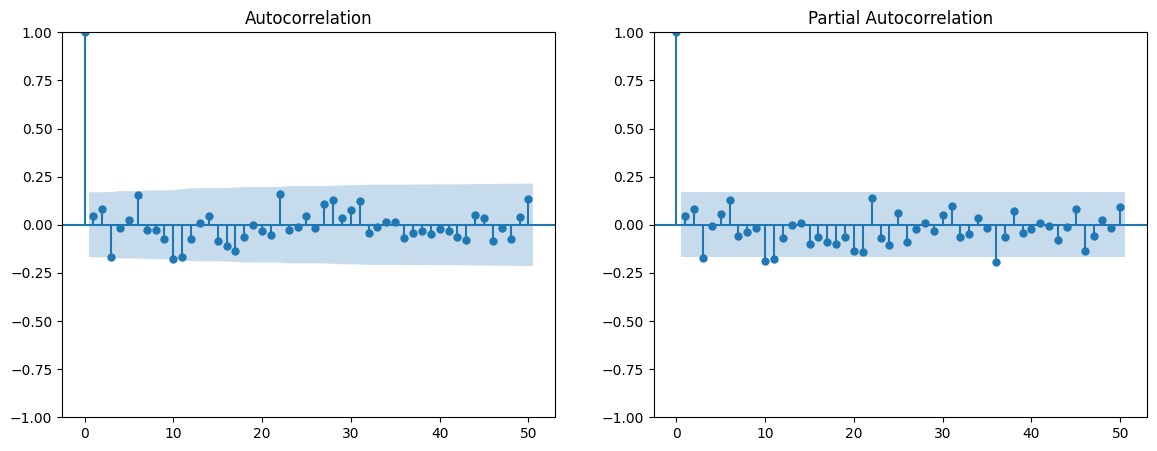

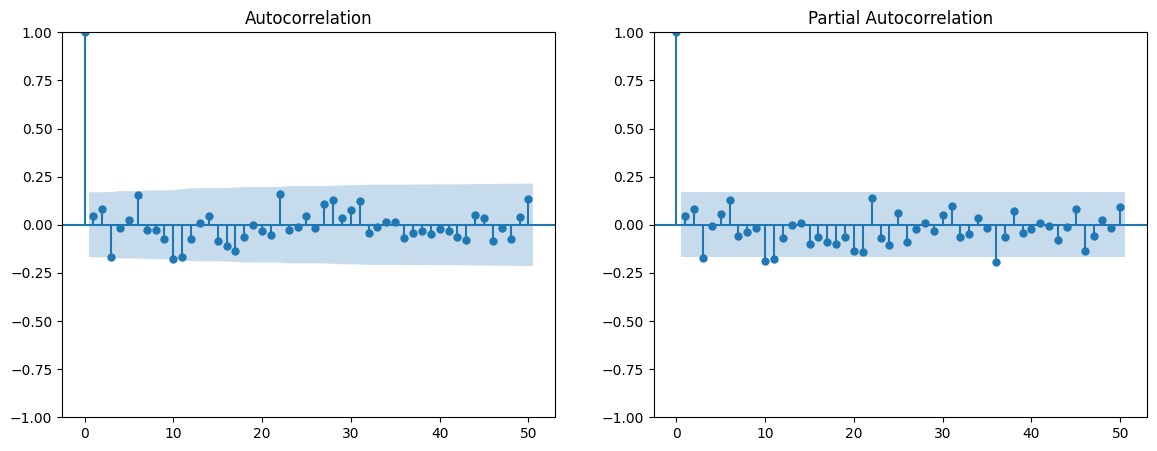

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(residuals, lags=50, ax=axes[0])
plot_pacf(residuals, lags=50, ax=axes[1])

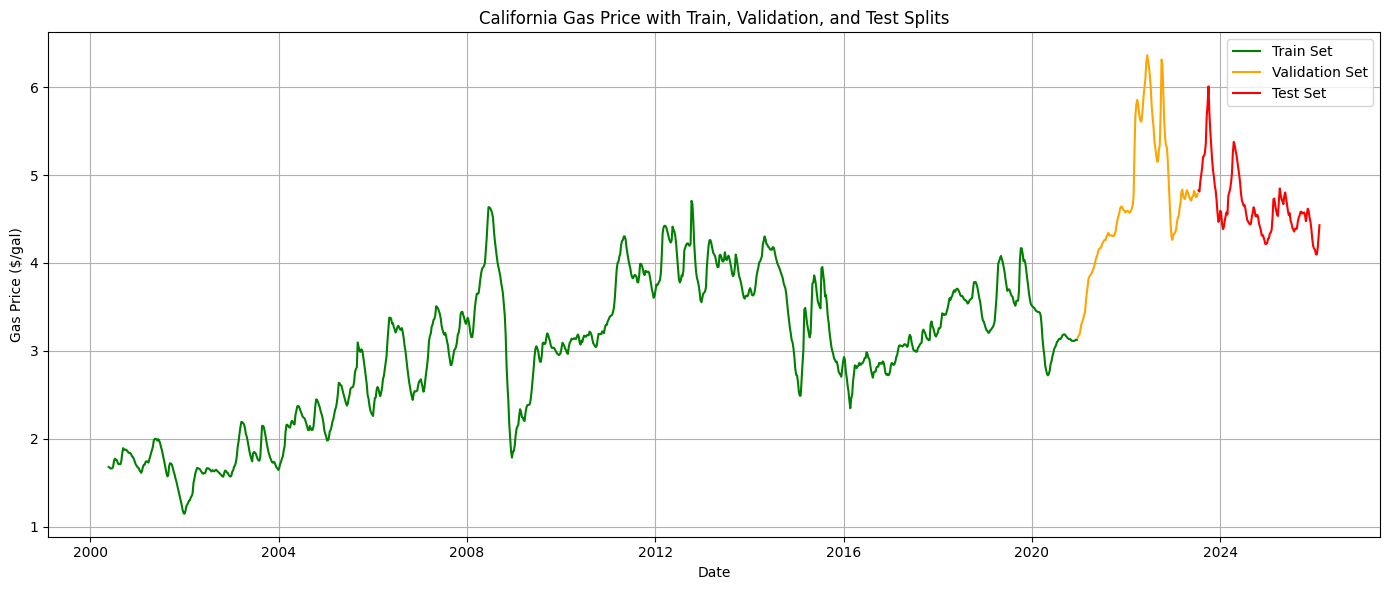

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CHRONOLOGICAL TRAIN / VAL / TEST PLOT
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(14, 6))

# Plot each segment of the gas price with different colors
plt.plot(df['date'].iloc[0:train_end], df['gas_price'].iloc[0:train_end], color='green', label='Train Set')
plt.plot(df['date'].iloc[train_end:val_end], df['gas_price'].iloc[train_end:val_end], color='orange', label='Validation Set')
plt.plot(df['date'].iloc[val_end:], df['gas_price'].iloc[val_end:], color='red', label='Test Set')

plt.title('California Gas Price with Train, Validation, and Test Splits')
plt.xlabel('Date')
plt.ylabel('Gas Price ($/gal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CREATE PYTORCH DATA LOADERS
# ─────────────────────────────────────────────────────────────────────────────

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32).to(device)

# Rebuild tensors — must rerun after any SEQ_LENGTH change
Xtr_m_t, ytr_m_t = to_tensor(Xtr_m), to_tensor(ytr_m)
Xva_m_t, yva_m_t = to_tensor(Xva_m), to_tensor(yva_m)
Xte_m_t, yte_m_t = to_tensor(Xte_m), to_tensor(yte_m)

loader_multi = DataLoader(TensorDataset(Xtr_m_t, ytr_m_t), batch_size=BATCH_SIZE, shuffle=False)
print(f"Loader ready — {len(loader_multi)} batches of size {BATCH_SIZE}")


Loader ready — 34 batches of size 32


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL DEFINITIONS  
# ─────────────────────────────────────────────────────────────────────────────

class VanillaRNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size, HIDDEN_SIZE, NUM_LAYERS,
                          batch_first=True, dropout=dropout_rate)
        self.fc = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, HIDDEN_SIZE, NUM_LAYERS,
                            batch_first=True, dropout=dropout_rate)
        self.fc = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, HIDDEN_SIZE, NUM_LAYERS,
                          batch_first=True, dropout=dropout_rate)
        self.fc = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

EPOCHS        = 50
PATIENCE      = 10
INPUT_SIZE    = 5

HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
OUTPUT_SIZE   = 1
LEARNING_RATE = 0.001

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_model(model, train_loader, X_val, y_val, epochs=EPOCHS, patience=PATIENCE, lr=LEARNING_RATE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)

    total_time = time.time() - t_start
    n_params   = count_params(model)

    return train_losses, val_losses, total_time, n_params

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN ALL MODELS  
# ─────────────────────────────────────────────────────────────────────────────

print('\n── Training LSTM  ───────────────────────')
lstm_multi = LSTMModel(input_size=INPUT_SIZE, dropout_rate=0.0).to(device)
tl_lstm_multi, vl_lstm_multi, time_lstm, params_lstm = train_model(lstm_multi, loader_multi, Xva_m_t, yva_m_t)

print('\n── Training GRU ────────────────────────')
gru_multi = GRUModel(input_size=INPUT_SIZE, dropout_rate=0.0).to(device)
tl_gru_multi, vl_gru_multi, time_gru, params_gru = train_model(gru_multi, loader_multi, Xva_m_t, yva_m_t)

print('\n── Training Vanilla RNN (dropout=0.1) ───────────────')
rnn_multi = VanillaRNN(input_size=INPUT_SIZE, dropout_rate=0.1).to(device)
tl_rnn_multi, vl_rnn_multi, time_rnn, params_rnn = train_model(rnn_multi, loader_multi, Xva_m_t, yva_m_t)

print('\n── Training Vanilla RNN (no dropout) ────────────────')
rnn_no_dropout = VanillaRNN(input_size=INPUT_SIZE, dropout_rate=0.0).to(device)
tl_rnn_no_dropout, vl_rnn_no_dropout, time_rnn_nd, params_rnn_nd = train_model(rnn_no_dropout, loader_multi, Xva_m_t, yva_m_t)


── Training LSTM  ───────────────────────
  Epoch 10/50 | Train: 0.0065 | Val: 0.0071
  Epoch 20/50 | Train: 0.0078 | Val: 0.0058
  Early stopping at epoch 26

── Training GRU ────────────────────────
  Epoch 10/50 | Train: 0.0024 | Val: 0.0052
  Epoch 20/50 | Train: 0.0015 | Val: 0.0032
  Epoch 30/50 | Train: 0.0016 | Val: 0.0012
  Epoch 40/50 | Train: 0.0083 | Val: 0.0026
  Epoch 50/50 | Train: 0.0015 | Val: 0.0009

── Training Vanilla RNN (dropout=0.1) ───────────────
  Epoch 10/50 | Train: 0.0026 | Val: 0.0039
  Epoch 20/50 | Train: 0.0015 | Val: 0.0020
  Epoch 30/50 | Train: 0.0016 | Val: 0.0014
  Epoch 40/50 | Train: 0.0016 | Val: 0.0014
  Early stopping at epoch 44

── Training Vanilla RNN (no dropout) ────────────────
  Epoch 10/50 | Train: 0.0022 | Val: 0.0065
  Epoch 20/50 | Train: 0.0014 | Val: 0.0056
  Epoch 30/50 | Train: 0.0015 | Val: 0.0018
  Epoch 40/50 | Train: 0.0014 | Val: 0.0013
  Epoch 50/50 | Train: 0.0013 | Val: 0.0011


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ROLLING ONE-STEP-AHEAD EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def rolling_evaluate(model, df_scaled, val_end, seq_len, scaler, n_features):
    model.eval()
    preds, actuals = [], []
    test_size = len(df_scaled) - val_end

    for i in range(test_size):
        window_start = max(0, val_end + i - seq_len)
        window = df_scaled[window_start : val_end + i]

        x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_scaled = model(x).cpu().numpy()[0, 0]

        # Inverse transform
        dummy       = np.zeros((1, n_features))
        dummy[0, 0] = pred_scaled
        pred_actual = scaler.inverse_transform(dummy)[0, 0]

        dummy[0, 0]   = df_scaled[val_end + i, 0]
        actual_actual = scaler.inverse_transform(dummy)[0, 0]

        preds.append(pred_actual)
        actuals.append(actual_actual)

    preds   = np.array(preds)
    actuals = np.array(actuals)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)
    pcc  = np.corrcoef(actuals, preds)[0, 1]
    return rmse, mae, r2, pcc, preds, actuals

rmse_lstm_multi, mae_lstm_multi, r2_lstm, pcc_lstm, preds_lstm_multi, actual = \
    rolling_evaluate(lstm_multi, scaled_multi, val_end, SEQ_LENGTH, scaler_multi, INPUT_SIZE)

rmse_gru_multi, mae_gru_multi, r2_gru, pcc_gru, preds_gru_multi, _ = \
    rolling_evaluate(gru_multi, scaled_multi, val_end, SEQ_LENGTH, scaler_multi, INPUT_SIZE)

rmse_rnn_multi, mae_rnn_multi, r2_rnn_multi, pcc_rnn_multi, preds_rnn_multi, _ = \
    rolling_evaluate(rnn_multi, scaled_multi, val_end, SEQ_LENGTH, scaler_multi, INPUT_SIZE)

rmse_rnn_no_dropout, mae_rnn_no_dropout, r2_rnn_no_dropout, pcc_rnn_no_dropout, preds_rnn_no_dropout, _ = \
    rolling_evaluate(rnn_no_dropout, scaled_multi, val_end, SEQ_LENGTH, scaler_multi, INPUT_SIZE)

print(f"{'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'PCC':>8} {'Time (s)':>10} {'Params':>8}")
print("-" * 56)
for name, rmse, mae, r2, pcc, time, params in [
    ("LSTM",          rmse_lstm_multi,     mae_lstm_multi,     r2_lstm,          pcc_lstm,      time_lstm, params_lstm),
    ("GRU",           rmse_gru_multi,      mae_gru_multi,      r2_gru,           pcc_gru,       time_gru, params_gru),
    ("RNN (0.1 dropout)",   rmse_rnn_multi,      mae_rnn_multi,      r2_rnn_multi,     pcc_rnn_multi, time_rnn, params_rnn),
    ("RNN (no dropout)",    rmse_rnn_no_dropout, mae_rnn_no_dropout, r2_rnn_no_dropout,pcc_rnn_no_dropout, time_rnn_nd, params_rnn_nd),
]:
    print(f"{name:<28} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {pcc:>8.4f} {time:>10.2f} {params:>8,}")

Model                            RMSE      MAE       R²      PCC   Time (s)   Params
--------------------------------------------------------
LSTM                           0.1876   0.1491   0.7253   0.8569       7.71  201,345
GRU                            0.0864   0.0680   0.9417   0.9762      25.94  151,041
RNN (0.1 dropout)              0.1142   0.0873   0.8982   0.9578      11.36   50,433
RNN (no dropout)               0.1030   0.0806   0.9172   0.9653      11.48   50,433


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Model Comparison ────────────────────────────────────")
print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 47)
print(f"{'ARIMAX':<25} {rmse_arima:>10.4f} {mae_arima:>10.4f}")
print(f"{'LSTM':<25} {rmse_lstm_multi:>10.4f} {mae_lstm_multi:>10.4f}")
print(f"{'GRU':<25} {rmse_gru_multi:>10.4f} {mae_gru_multi:>10.4f}")
print(f"{'Vanilla RNN (0.1 Dropout)':<25} {rmse_rnn_multi:>10.4f} {mae_rnn_multi:>10.4f}")
print(f"{'Vanilla RNN (No Dropout)':<25} {rmse_rnn_no_dropout:>10.4f} {mae_rnn_no_dropout:>10.4f}")


── Model Comparison ────────────────────────────────────
Model                           RMSE        MAE
-----------------------------------------------
ARIMAX                        0.0701     0.0491
LSTM                          0.1876     0.1491
GRU                           0.0864     0.0680
Vanilla RNN (0.1 Dropout)     0.1142     0.0873
Vanilla RNN (No Dropout)      0.1030     0.0806


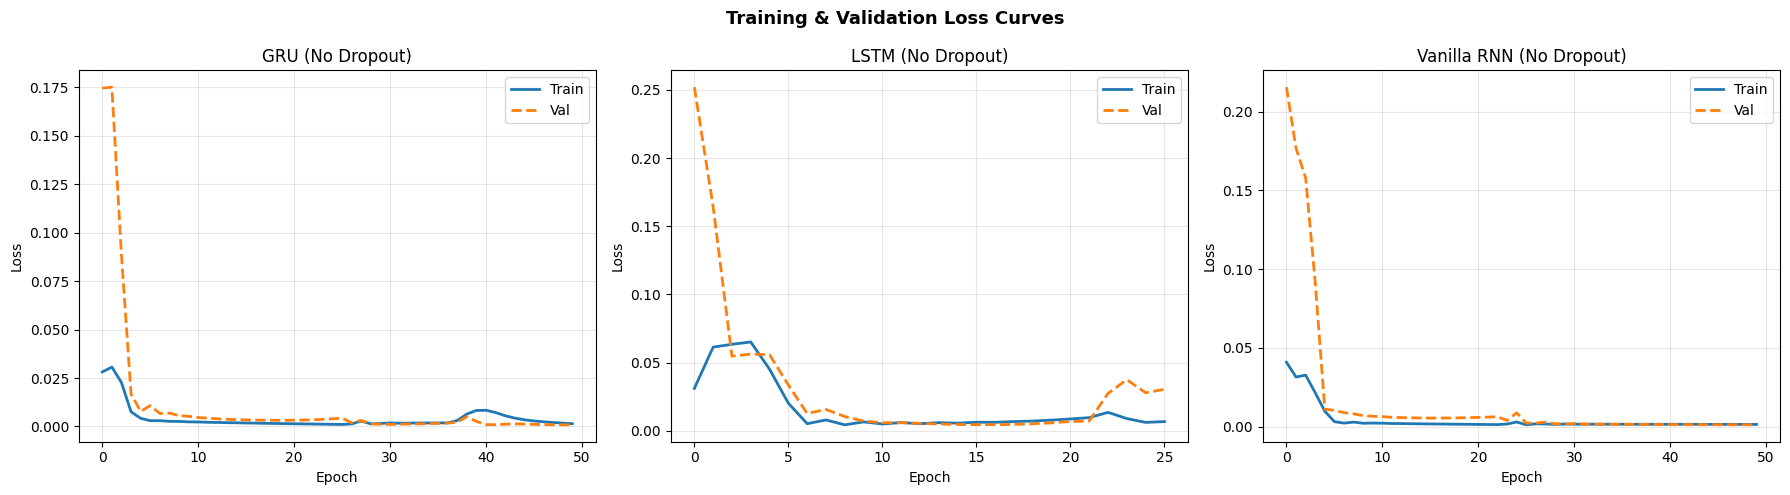

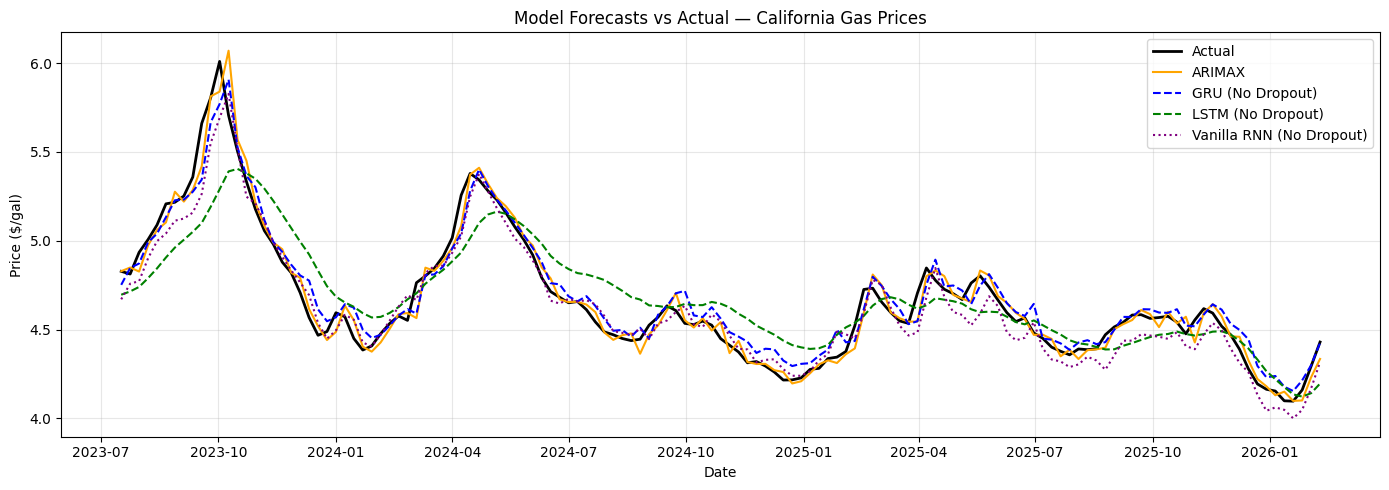

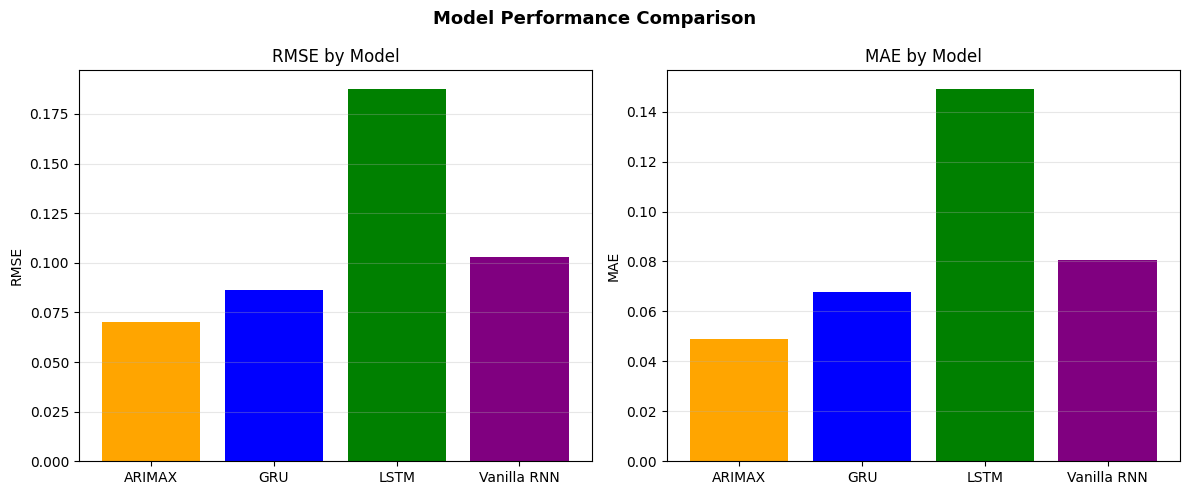

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOSS CURVES
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loss_data = [
    (tl_gru_multi,        vl_gru_multi,        'GRU (No Dropout)'),
    (tl_lstm_multi,       vl_lstm_multi,        'LSTM (No Dropout)'),
    (tl_rnn_no_dropout,   vl_rnn_no_dropout,    'Vanilla RNN (No Dropout)'),
]

for i, (tl, vl, title) in enumerate(loss_data):
    ax = axes[i]
    ax.plot(tl, label='Train', linewidth=2)
    ax.plot(vl, label='Val',   linewidth=2, linestyle='--')
    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FORECAST COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

prediction_dates = df['date'].iloc[val_end:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(prediction_dates, actual,              label='Actual',              color='black',  linewidth=2)
plt.plot(prediction_dates, arima_preds,         label='ARIMAX',              color='orange', linewidth=1.5)
plt.plot(prediction_dates, preds_gru_multi,     label='GRU (No Dropout)',    color='blue',   linestyle='--', linewidth=1.5)
plt.plot(prediction_dates, preds_lstm_multi,    label='LSTM (No Dropout)',   color='green',  linestyle='--', linewidth=1.5)
plt.plot(prediction_dates, preds_rnn_no_dropout,label='Vanilla RNN (No Dropout)', color='purple', linestyle=':', linewidth=1.5)

plt.title('Model Forecasts vs Actual — California Gas Prices')
plt.xlabel('Date')
plt.ylabel('Price ($/gal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BAR CHART 
# ─────────────────────────────────────────────────────────────────────────────

models = ['ARIMAX', 'GRU', 'LSTM', 'Vanilla RNN']
rmses  = [rmse_arima,     rmse_gru_multi,  rmse_lstm_multi,  rmse_rnn_no_dropout]
maes   = [mae_arima,      mae_gru_multi,   mae_lstm_multi,   mae_rnn_no_dropout]
colors = ['orange', 'blue', 'green', 'purple']

x = np.arange(len(models))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x, rmses, color=colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_title('RMSE by Model'); axes[0].set_ylabel('RMSE')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, maes, color=colors)
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_title('MAE by Model'); axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GRU ABLATION STUDY  
# ─────────────────────────────────────────────────────────────────────────────

# ── Config grid ──────────────────────────────────────────────────────────────
hidden_sizes    = [32, 64, 128]
dropout_rates   = [0.0, 0.1, 0.2]
lookback_windows = [12, 25, 52]

# Default values (keep one dimension fixed while sweeping another)
DEFAULT_HIDDEN  = 128
DEFAULT_DROPOUT = 0.0
DEFAULT_LOOKBACK = 12

ablation_results = []

def run_gru_ablation(hidden_size, dropout_rate, seq_len, label_dim, label_val):
    """Train a GRU with given config and return RMSE, MAE on test set."""
    torch.manual_seed(41)
    np.random.seed(41)

    train_s = scaled_multi[:train_end]
    val_context_  = np.concatenate([scaled_multi[train_end - seq_len:train_end],
                                    scaled_multi[train_end:val_end]], axis=0)
    test_context_ = np.concatenate([scaled_multi[val_end - seq_len:val_end],
                                    scaled_multi[val_end:]], axis=0)

    Xtr_, ytr_ = create_sequences(train_s, seq_len)
    Xva_, yva_ = create_sequences(val_context_,  seq_len)

    ytr_ = ytr_.reshape(-1, 1)
    yva_ = yva_.reshape(-1, 1)

    Xtr_t = torch.tensor(Xtr_, dtype=torch.float32).to(device)
    ytr_t = torch.tensor(ytr_, dtype=torch.float32).to(device)
    Xva_t = torch.tensor(Xva_, dtype=torch.float32).to(device)
    yva_t = torch.tensor(yva_, dtype=torch.float32).to(device)

    loader_ = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, shuffle=False)

    class _GRU(nn.Module):
        def __init__(self):
            super().__init__()
            self.gru = nn.GRU(INPUT_SIZE, hidden_size, NUM_LAYERS,
                              batch_first=True,
                              dropout=dropout_rate if NUM_LAYERS > 1 else 0.0)
            self.fc  = nn.Linear(hidden_size, OUTPUT_SIZE)
        def forward(self, x):
            out, _ = self.gru(x)
            return self.fc(out[:, -1, :])

    model = _GRU().to(device)

    # Train
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    best_val, best_state, no_improve = float("inf"), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for Xb, yb in loader_:
            optimizer.zero_grad()
            criterion(model(Xb), yb).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            vl = criterion(model(Xva_t), yva_t).item()
        scheduler.step(vl)
        if vl < best_val:
            best_val   = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break
    model.load_state_dict(best_state)

    # Evaluate
    rmse, mae, _, _, _, _ = rolling_evaluate(
        model, scaled_multi, val_end, seq_len, scaler_multi, INPUT_SIZE
    )
    return rmse, mae

# ── Sweep 1: Hidden Size  (dropout=DEFAULT, lookback=DEFAULT) ─────────────
print("Sweeping hidden size...")
for hs in hidden_sizes:
    rmse, mae = run_gru_ablation(hs, DEFAULT_DROPOUT, DEFAULT_LOOKBACK, "hidden_size", hs)
    ablation_results.append({"dimension": "Hidden Size", "config": str(hs), "RMSE": rmse, "MAE": mae})
    print(f"  hidden={hs:<4}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# ── Sweep 2: Dropout  (hidden=DEFAULT, lookback=DEFAULT) ──────────────────
print("Sweeping dropout...")
for dr in dropout_rates:
    rmse, mae = run_gru_ablation(DEFAULT_HIDDEN, dr, DEFAULT_LOOKBACK, "dropout", dr)
    ablation_results.append({"dimension": "Dropout", "config": str(dr), "RMSE": rmse, "MAE": mae})
    print(f"  dropout={dr}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# ── Sweep 3: Lookback Window  (hidden=DEFAULT, dropout=DEFAULT) ────────────
print("Sweeping lookback window...")
for lb in lookback_windows:
    rmse, mae = run_gru_ablation(DEFAULT_HIDDEN, DEFAULT_DROPOUT, lb, "lookback", lb)
    ablation_results.append({"dimension": "Lookback (wks)", "config": str(lb), "RMSE": rmse, "MAE": mae})
    print(f"  lookback={lb:<3}  RMSE={rmse:.4f}  MAE={mae:.4f}")

ablation_df = pd.DataFrame(ablation_results)

# Highlight best (lowest RMSE) within each dimension
def highlight_best(df):
    styled = df.style.apply(
        lambda row: [
            "background-color: #d4edda; font-weight: bold"
            if row["RMSE"] == df[df["dimension"] == row["dimension"]]["RMSE"].min()
            else "" for _ in row
        ],
        axis=1
    ).format({"RMSE": "{:.4f}", "MAE": "{:.4f}"})      .set_caption("GRU Ablation Study — Rolling One-Step-Ahead Test Performance")      .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "th",      "props": [("background-color", "#343a40"), ("color", "white"), ("padding", "8px 14px")]},
        {"selector": "td",      "props": [("padding", "7px 14px"), ("border-bottom", "1px solid #dee2e6")]},
        {"selector": "tr:hover","props": [("background-color", "#f1f3f5")]},
    ])
    return styled

display(highlight_best(ablation_df))


Sweeping hidden size...
  hidden=32    RMSE=0.1834  MAE=0.1508
  hidden=64    RMSE=0.1238  MAE=0.0979
  hidden=128   RMSE=0.0942  MAE=0.0718
Sweeping dropout...
  dropout=0.0  RMSE=0.0942  MAE=0.0718
  dropout=0.1  RMSE=0.1021  MAE=0.0794
  dropout=0.2  RMSE=0.1659  MAE=0.1276
Sweeping lookback window...
  lookback=12   RMSE=0.0942  MAE=0.0718
  lookback=25   RMSE=0.0927  MAE=0.0716
  lookback=52   RMSE=0.0950  MAE=0.0766


,dimension,config,RMSE,MAE
0,Hidden Size,32,0.1834,0.1508
1,Hidden Size,64,0.1238,0.0979
2,Hidden Size,128,0.0942,0.0718
3,Dropout,0.0,0.0942,0.0718
4,Dropout,0.1,0.1021,0.0794
5,Dropout,0.2,0.1659,0.1276
6,Lookback (wks),12,0.0942,0.0718
7,Lookback (wks),25,0.0927,0.0716
8,Lookback (wks),52,0.0950,0.0766


In [24]:
last_date = df['date'].iloc[-1].strftime('%Y-%m-%d')
actual_last = actual[-1]

print(f"\nFinal Test Step — Date: {last_date}")
print(f"{'Model':<28} {'Predicted':>12} {'Actual':>12} {'Error':>10}")
print("-" * 65)
for name, preds in [
    ("ARIMAX",          rolling_preds),
    ("LSTM",            preds_lstm_multi),
    ("GRU",             preds_gru_multi),
    ("RNN (no dropout)", preds_rnn_no_dropout),
]:
    pred  = preds[-1]
    error = pred - actual_last
    print(f"{name:<28} {pred:>12.4f} {actual_last:>12.4f} {error:>10.4f}")


Final Test Step — Date: 2026-02-09
Model                           Predicted       Actual      Error
-----------------------------------------------------------------
ARIMAX                             4.3348       4.4300    -0.0952
LSTM                               4.1961       4.4300    -0.2339
GRU                                4.4257       4.4300    -0.0043
RNN (no dropout)                   4.3170       4.4300    -0.1130


In [25]:
# Collect all metrics for the report
print("=== DATASET INFO ===")
print(f"Total observations: {len(df)}")
print(f"Date range: {df['date'].iloc[0]} to {df['date'].iloc[-1]}")
print(f"Train size: {train_end} ({train_end/len(df)*100:.1f}%)")
print(f"Val size: {val_end - train_end} ({(val_end-train_end)/len(df)*100:.1f}%)")
print(f"Test size: {len(df) - val_end} ({(len(df)-val_end)/len(df)*100:.1f}%)")
print(f"\nTrain seq shape: {Xtr_m.shape}")
print(f"Val seq shape: {Xva_m.shape}")
print(f"Test seq shape: {Xte_m.shape}")

print("\n=== ARIMAX ===")
print(f"Best order: {best_order}")
print(f"RMSE: {rmse_arima:.4f}")
print(f"MAE: {mae_arima:.4f}")

print("\n=== RNN MODELS ===")
for name, rmse, mae, r2 in [
    ("LSTM Multi", rmse_lstm_multi, mae_lstm_multi, r2_lstm),
    ("GRU Multi", rmse_gru_multi, mae_gru_multi, r2_gru),
    ("RNN (0.1)", rmse_rnn_multi, mae_rnn_multi, r2_rnn_multi),
    ("RNN (NoDrop)", rmse_rnn_no_dropout, mae_rnn_no_dropout, r2_rnn_no_dropout),
]:
    print(f"{name:15s} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
print("Hidden Size:", HIDDEN_SIZE)
print("SEQ_LENGTH:", SEQ_LENGTH )

print("\n=== CORRELATION MATRIX ===")
print(df[FEATURE_COLS].corr().round(4))

print("\n=== DESCRIPTIVE STATS ===")
print(df[FEATURE_COLS].describe().round(4))

print(f"\n=== HYPERPARAMETERS ===")
print(f"SEQ_LENGTH={SEQ_LENGTH}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, PATIENCE={PATIENCE}")
print(f"HIDDEN_SIZE={HIDDEN_SIZE}, NUM_LAYERS={NUM_LAYERS}, LR={LEARNING_RATE}")
print(f"Device: {device}")
print(f"Seed: 43")

print("\n=== TRAINING EPOCHS ===")
print(f"LSTM: {len(tl_lstm_multi)} epochs")
print(f"GRU: {len(tl_gru_multi)} epochs")
print(f"RNN (0.1): {len(tl_rnn_multi)} epochs")
print(f"RNN (NoDrop): {len(tl_rnn_no_dropout)} epochs")

print(f"\n=== ARIMA GRID SEARCH ===")
print(f"Stable configs: {len(results_log)}")
print(f"Total configs tested: {count}")

=== DATASET INFO ===
Total observations: 1343
Date range: 2000-05-22 00:00:00 to 2026-02-09 00:00:00
Train size: 1074 (80.0%)
Val size: 134 (10.0%)
Test size: 135 (10.1%)

Train seq shape: (1062, 12, 5)
Val seq shape: (134, 12, 5)
Test seq shape: (135, 12, 5)

=== ARIMAX ===
Best order: (1, 1, 1)
RMSE: 0.0701
MAE: 0.0491

=== RNN MODELS ===
LSTM Multi      RMSE=0.1876  MAE=0.1491  R2=0.7253
GRU Multi       RMSE=0.0864  MAE=0.0680  R2=0.9417
RNN (0.1)       RMSE=0.1142  MAE=0.0873  R2=0.8982
RNN (NoDrop)    RMSE=0.1030  MAE=0.0806  R2=0.9172
Hidden Size: 128
SEQ_LENGTH: 12

=== CORRELATION MATRIX ===
                  gas_price  wti_price  padd5_inventory  refinery_util  \
gas_price            1.0000     0.7627          -0.1841        -0.0524   
wti_price            0.7627     1.0000          -0.1032        -0.1454   
padd5_inventory     -0.1841    -0.1032           1.0000        -0.1062   
refinery_util       -0.0524    -0.1454          -0.1062         1.0000   
product_supplied     0.